# Demonstrating `uncertainty` module

In this notebook we show the how to use and apply the classess and method in the sub modules of the `uncertainty` module this include:
- Importing uncertainty information
- Filtering uncertain parameters
- selecting and changing probability distribution information of uncertain parameters

In [3]:
%load_ext autoreload
%autoreload 2
import os
import sys
import pandas as pd
import numpy as np
sys.path.append('..')
from pulpo import pulpo
from pulpo.utils.uncertainty import preparer, processor, plots, gsa
from pulpo.utils import optimizer, saver

## 0. Setup Background and Foreground Databases

### 0.1: Background Database (Ecoinvent 3.10 cutoff)

In [2]:
from pathlib import Path
import bw2data as bd
import bw2io as bi

PROJECT = "ammonia_final"
DB_NAME = "ecoinvent-3.10-cutoff"
CRED_PATH = Path("/Users/hausslingbhl/Library/CloudStorage/OneDrive-UniversiteitLeiden/01_Administration/02_VITO/04_Systems/credentials.txt")

def read_credentials(path: Path):
    if not path.is_file():
        raise FileNotFoundError(f"Couldn't find credentials file at: {path.resolve()}")
    creds = {}
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        # allow "key=value" or "key: value" or "key value"
        for sep in ("=", ":", " "):
            if sep in line:
                k, v = line.split(sep, 1)
                creds[k.strip().lower()] = v.strip()
                break
    if "username" not in creds or "password" not in creds:
        raise ValueError("credentials.txt must contain 'username' and 'password'.")
    return creds["username"], creds["password"]

# 1) Ensure project exists / is selected
bd.projects.set_current(PROJECT)

# 2) Import ecoinvent 3.10 cutoff if missing
if DB_NAME in bd.databases:
    print(f"Database '{DB_NAME}' already exists in project '{bd.projects.current}'.")
else:
    username, password = read_credentials(CRED_PATH)
    bi.import_ecoinvent_release(
        version="3.10",
        system_model="cutoff",  # "cutoff", "apos", "consequential", or "EN15804"
        username=username,
        password=password,
    )
    print(f"Database '{DB_NAME}' installed successfully.")

Database 'ecoinvent-3.10-cutoff' already exists in project 'ammonia_final'.


### 0.2: Foreground Database (Ammonia Production)

In [3]:
# Path to your Excel file
excel_path = r"data/ammonia.xlsx"
fg_db_name = "ammonia"

if fg_db_name in bd.databases:
    print(f"Database '{fg_db_name}' already exists in project '{bd.projects.current}'.")
else:
    # 1. Import the Excel file
    fg_db = bi.ExcelImporter(excel_path)

    # 2. Apply strategies to clean and prepare the data
    fg_db.apply_strategies()

    # 3. Match the foreground database to itself (for internal links)
    fg_db.match_database(fields=["name", "unit", "reference product", "location"])

    # 4. Match to ecoinvent technosphere (use your actual ecoinvent db name)
    fg_db.match_database(
        "ecoinvent-3.10-cutoff",
        fields=["name", "unit", "location", "reference product"]
    )

    # 5. Match to ecoinvent biosphere (biosphere db is usually auto-named, check with list(bd.databases))
    biosphere_db = [db for db in bd.databases if "biosphere" in db and "3.10" in db][0]
    fg_db.match_database(
        biosphere_db,
        fields=["name", "categories", "location"]
    )

    # 6. Check statistics (should have 0 unlinked exchanges)
    fg_db.statistics()

    # 7. Write the database to disk
    fg_db.write_database()
    print(f"Database '{fg_db_name}' installed successfully.")

Database 'ammonia' already exists in project 'ammonia_final'.


### 0.3: Install premise for GWP characterization factors

**Note:** Before executing the next cell, make sure to install `premise` via:
```bash
pip install premise
```

This package is required for adding updated GWP characterization factors to the project.

In [4]:

# Check if the IPCC 2021 method already exists before adding premise GWP
import bw2data as bd

target_method = ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')

if target_method in bd.methods:
    print(f"Method '{target_method}' already exists in the project.")
else:
    print(f"Method '{target_method}' not found. Adding premise GWP characterization factors...")
    from premise_gwp import add_premise_gwp
    add_premise_gwp()
    print("Premise GWP characterization factors added successfully.")

Method '('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')' already exists in the project.


## 1. Case Study Setup: Ammonia Production System

In [4]:
def setup_ammonia_case_study():
    """
    Set up the ammonia production case study with PULPO configuration.
    
    Returns:
        tuple: (project, database, method, directory) configuration parameters
    """
    project = "ammonia_final"
    database = ["ecoinvent-3.10-cutoff", "ammonia"]
    method = "('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')"
    directory = "develop_tests"
    
    return project, database, method, directory

def create_pulpo_worker(project, database, method, directory):
    """
    Create and initialize a PULPO optimizer instance.
    
    Args:
        project (str): PULPO project name
        database (str): Database name
        method (str): LCIA method specification
        directory (str): Working directory path
        
    Returns:
        pulpo.PulpoOptimizer: Configured PULPO worker instance
    """
    # Create PulpoOptimizer instance
    pulpo_worker = pulpo.PulpoOptimizer(project, database, method, directory)
    pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
    
    # Import LCI data
    pulpo_worker.get_lci_data()
    
    return pulpo_worker

def get_single_process(worker, query, prefer_locations=("RER", "Europe", "GLO")):
    """
    Deterministic process retrieval to avoid order issues.
    
    Args:
        worker: PULPO optimizer instance
        query (str): Process name query
        prefer_locations (tuple): Preferred locations in order of preference
        
    Returns:
        Process object from the database
    """
    matches = worker.retrieve_processes(processes=query)
    if not matches:
        raise ValueError(f"No process found for query: {query}")
    for loc in prefer_locations:
        for p in matches:
            if getattr(p, "location", None) == loc or loc in str(p):
                return p
    return sorted(matches, key=lambda x: str(x))[0]

def define_ammonia_problem(pulpo_worker):
    """
    Define the ammonia production optimization problem with streamlined configuration.
    
    Args:
        pulpo_worker: PULPO optimizer instance
        
    Returns:
        tuple: (choices, demand) for the optimization problem
    """
    # Choice definitions with capacities bound per-label
    choice_config = {
        "biogas": {
            "processes": [
                "anaerobic digestion of agricultural residues",
                "anaerobic digestion of sequential crop",
            ],
            # 2030 EU-27 potentials from biomethane shares (38 bcm total; 24% ag, 21% sequential),
            # converted to raw biogas assuming ~57% CH₄ → 16.0 & 14.0 bcm ≈ 1.60e10 & 1.40e10 m³/yr.
            "capacities": [1.60e10, 1.40e10],
        },
        "biomethane": {
            "processes": [
                "upgrading water scrubbing (CCS)",
                "upgrading water scrubbing",
                "upgrading chemical scrubbing",
                "upgrading chemical scrubbing (CCS)",
            ],
            "capacities": [1e20, 1e20, 1e20, 1e20],
        },
        "methane": {
            "processes": ["market for methane fg", "market for biomethane"],
            "capacities": [1e20, 1e20],
        },
        "heat": {
            "processes": ["heat from methane", "heat from methane (CCS)", "heat from hydrogen"],
            "capacities": [1e20, 1e20, 1e20],
        },
        "hydrogen": {
            "processes": [
                "methane pyrolysis",
                "steam methane reforming",
                "steam methane reforming (CCS)",
                "plastics gasification",
                "plastics gasification (CCS)",
                "alkaline electrolysis",
                "PEM electrolysis",
            ],
            # Methane pyrolysis capped to 10,000 t H2/yr (= 1.0e7 kg/yr); others left high for now.
            "capacities": [1.0e7, 1e20, 1e20, 1e20, 1e20, 1e20, 1e20],
        },
        "electricity": {
            "processes": [
                "grid electricity",
                "wind onshore electricity",
            ],
            "capacities": [1e20, 1e10], # Placeholder cap for wind onshore
        },
        "ammonia": {
            "processes": [
                "steam reforming, integrated",
                "steam reforming, integrated (CCS)",
                "nitrogen + hydrogen",
            ],
            "capacities": [1e20, 1e20, 1e20],
        },
    }

    # Build choices with deterministic mapping
    choices = {}
    for category, cfg in choice_config.items():
        labels, caps = cfg["processes"], cfg["capacities"]
        if len(labels) != len(caps):
            raise ValueError(f"Length mismatch in '{category}': {len(labels)} labels vs {len(caps)} capacities")
        choices[category] = {get_single_process(pulpo_worker, lbl): cap for lbl, cap in zip(labels, caps)}

    # Demand (EU ammonia, kg/yr)
    demand_process = get_single_process(pulpo_worker, "market for ammonia")
    demand = {demand_process: 17.1e9}  # ~17.1 Mt/yr (EU)

    # Additional upper bounds (shared resources / feedstocks)
    waste_pp = get_single_process(pulpo_worker, "treatment of waste PP")
    waste_ps = get_single_process(pulpo_worker, "treatment of waste PS")
    ccs_process = get_single_process(pulpo_worker, "CCS 200km pipeline 1000m deep")

    upper_bounds = {
        waste_pp: 1.875e9,  # 25% of ~7.5 Mt PP post-consumer waste ≈ 1.875 Mt/yr
        waste_ps: 3.25e8,   # 25% of ~1.3 Mt PS waste ≈ 0.325 Mt/yr
        ccs_process: 5.0e9, # 5 MtCO2/yr (10% of EU-27 2030 NZIA target)
    }
    
    # Instantiate the optimization problem
    pulpo_worker.instantiate(demand=demand, choices=choices, upper_limit=upper_bounds)
    
    return choices, demand

def solve_and_summarize(pulpo_worker, file_name='ammonia_results'):
    """
    Solve the optimization problem and summarize results.
    
    Args:
        pulpo_worker: PULPO optimizer instance
        file_name (str): Filename for results (optional)
        
    Returns:
        dict: Extracted results data
    """
    # Solve optimization problem
    pulpo_worker.solve()
    
    # Extract and summarize results
    result_data = pulpo_worker.extract_results()
    pulpo_worker.summarize_results(zeroes=True)
    
    return result_data

In [5]:
# Set up the ammonia case study
project, database, method, directory = setup_ammonia_case_study()

# Create and initialize PULPO worker
pulpo_worker = create_pulpo_worker(project, database, method, directory)

# Define the optimization problem
choices, demand = define_ammonia_problem(pulpo_worker)

# Solve the problem and get results
result_data = solve_and_summarize(pulpo_worker, file_name='ammonia_test')

print(f"✅ Setup complete: {sum(len(c) for c in choices.values())} alternatives across {len(choices)} categories")

Creating Instance
Instance created
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47123 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47123 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23546 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23563 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  18465929242.87779


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')",1,1.846593e+10


## Choices Made

### biogas

...

,Value,Capacity
Metadata,,
nitrogen + hydrogen | ammonia | RER,1.710000e+10,1.000000e+20


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23523,"(ammonia, fc378c5b9e61e417e77ba0c166897da5_copy1)",CCS 200km pipeline 1000m deep | CO2 stored | RER,5.000000e+09,5.000000e+09


✅ Setup complete: 23 alternatives across 7 categories


## 2. Filtering out negletable uncertain parameters

We only consider uncertainty in the $B$ and $Q$ parameter matrizes. The scaling vector is given by the optimal solution.

The parameter filter, aims to reduce the set of uncertain parameters to reduce the computational effort for the GSA or for CC optimization. 

There is however an inherent risk when reducing the set of parameters before using chance constraint optimization, since relevant uncertain parameters at the non deterministic solution might be filtered out, which can be significant at higher probability levels.

In [6]:
paramfilter = preparer.ParameterFilter(
    lci_data=pulpo_worker.lci_data, 
    choices = choices,
    demand = demand,
    method = method
    )

Using the basic scaling vector which only includes the optimal choices in the scaling vector

In [7]:
scaling_vector_series = paramfilter.prepare_scaling_vector(scaling_vector_strategy='naive', result_data=result_data)

Using the scaling vector constructed from all choices

In [8]:
scaling_vector_series = paramfilter.prepare_scaling_vector(scaling_vector_strategy='constructed_demand')

Compute the LCA scores and return the characterized inventory to be used for the filtering

In [9]:
lca_score, characterized_inventory = paramfilter.compute_LCI_LCIA(scaling_vector_series)

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 7.171627e+01


Plot the largest contributors

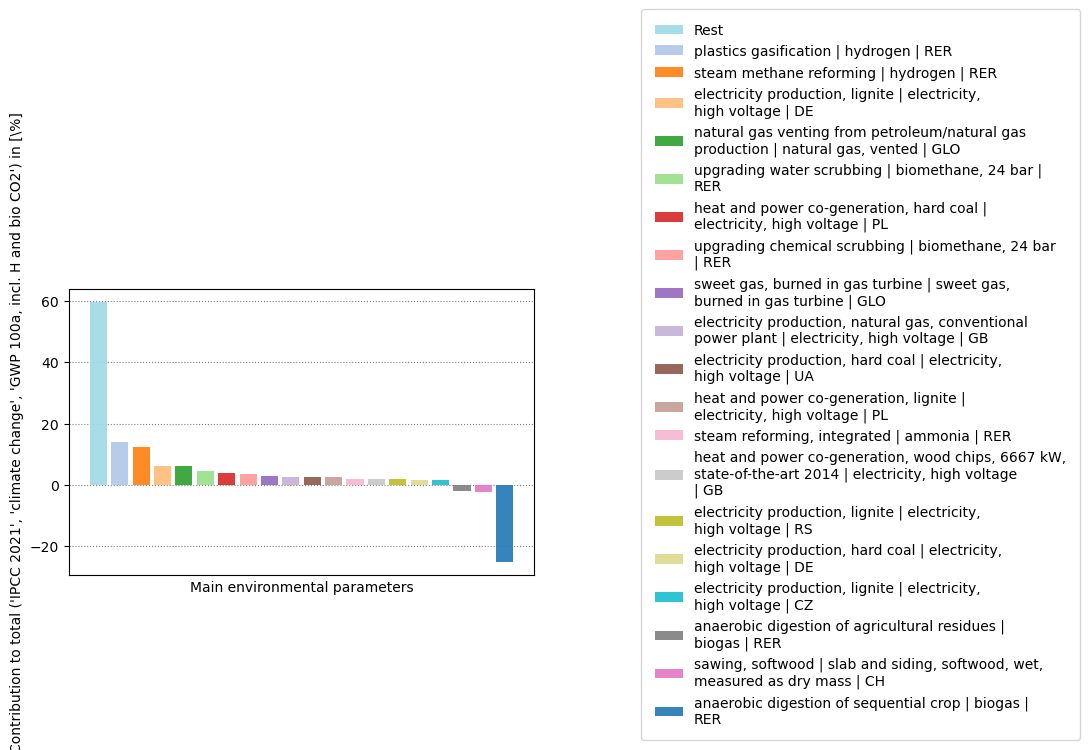

In [10]:
plots.plot_top_characterized_processes(pulpo_worker.lci_data['process_map_metadata'], characterized_inventory, method, top_amount=19)

Filtering out the inventoryflows $B_{i,j}$ that have a neglectable impact

In [11]:
cutoff = 0.000019 # ATTN: Change to 0. to include all parameters, this is needed to include the CCS biosphere flows else they are filtered out
# cutoff = 0.
filtered_inventory_indcs = paramfilter.filter_inventoryflows(characterized_inventory, lca_score, cutoff)

Characterized inventory: (2648, 23569) 26623
Filtered characterized inventory: (2648, 23569) 1016
Deviation from LCA score: 0.009760300057592874
inventory (2648, 23569) filtering resulted in 1016 of 26623 exchanges (99.02% of total impact) and took 0.05 seconds.


In [12]:
filtered_characterization_indcs = paramfilter.filter_characterization_factors(filtered_inventory_indcs)

CHARACTERIZATION MATRIX (2648,) filtering resulted in 29 of 112 characterization factors


### 2.1. Filtering method
Alternativly all the methods can be called with the `apply_filter` method.

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 7.171627e+01


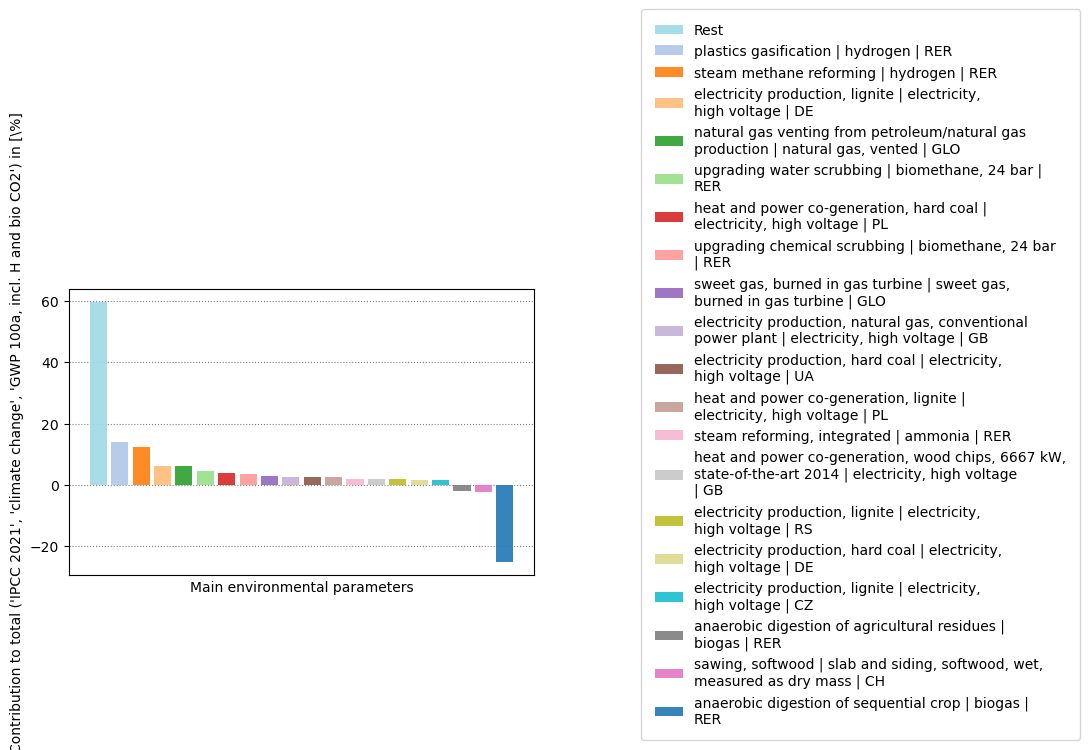

Characterized inventory: (2648, 23569) 26623
Filtered characterized inventory: (2648, 23569) 26623
Deviation from LCA score: 0.0
inventory (2648, 23569) filtering resulted in 26623 of 26623 exchanges (100.0% of total impact) and took 0.005 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 100 of 112 characterization factors


In [13]:
filtered_inventory_indcs, filtered_characterization_indcs = paramfilter.apply_filter(
    scaling_vector_strategy='constructed_demand',
    cutoff=0.,#0.001,
    plot_results=True,
    plot_n_top_processes=19
)

## 3. Getting the uncertainty of the parameter values

### 3.1. Importing the uncertainty data

Imports uncertainty data for the intervention flows and the characterization factors from the databases and Brightway project. It also creates uncertainty data (with unspecified distributions) for the variables bounds specified for the pulpo instance.

Extracts the metadata containing the uncertainty information to the filtered intervention flows and seperate the metadata into the parameters with and without defined uncertainty information

In [15]:
uncertainty_importer = preparer.UncertaintyImporter(
    lci_data=pulpo_worker.lci_data, 
    bw_databases=database, 
    LCIA_method=method,
)
uncertainty_data = uncertainty_importer.import_uncertainty_data(
    if_indcs=filtered_inventory_indcs,
    cf_indcs=filtered_characterization_indcs,
    choices=pulpo_worker.choices,
    upper_limit=pulpo_worker.upper_limit,
    lower_limit=pulpo_worker.lower_limit,
    upper_elem_limit=pulpo_worker.upper_elem_limit,
    upper_imp_limit=pulpo_worker.upper_imp_limit,
)

Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 19912 
Parameters without uncertainty information: 6656
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 55
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 100
Variable bounds:
Upper bound from choices without uncertainty information: 23
Upper bound from `upper_limit` without uncertainty information: 3
Lower bound from `lower_limit` without uncertainty information: 0


### 3.2. Apply strategies to define missing uncertainty data

#### 3.2.1. Intervention flows

In [16]:
print(database)

['ecoinvent-3.10-cutoff', 'ammonia']


Apply the triangular strategy using bound interpolation to the missing intervention uncertainty parameters in the background database

In [17]:
if_bg_triangular_strategy = processor.TriangularBoundInterpolationStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ecoinvent-3.10-cutoff',
    noise_interval={'min':.1, 'max':.1}
    )
if_bg_triangular_strategy.assign(uncertainty_data)

upper spread statistics
mean: 1.9299
mode: 0    3.466758
dtype: float64
median: 0.9529
std: 7.4716
min: 0.0287
max: 786.9859


lower spread statistics
mean: 0.6154
mode: 0    0.776124
dtype: float64
median: 0.4879
std: 7.2151
min: 0.0279
max: 786.9859

The upper spread scaling factor for intervention flows is: 0.9529236746994976
The lower spread scaling factor for intervention flows is: 0.4879472130749054


Apply the Uniform strategy for the uncertainty parameters in the foreground database

In [18]:
if_fg_uniform_strategy = processor.UniformBaseStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ammonia',
    upper_scaling_factor = .5,
    lower_scaling_factor = .5,
    noise_interval={'min':.2, 'max':.2}
)
if_fg_uniform_strategy.assign(uncertainty_data)

Set expert judgement uncertainties to a few selected intervention flows:

In [19]:
# ATTN: It might be better to not call an index directly but search for the process and the intervention flow, just not sure how
# This can be done in a step before which returns the indices and can be called like defined here
'''
CCS_expert_uncertainty_info = {
    (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    }
if_fg_expert_knowledge_strategy = processor.ExpertKnowledgeStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ammonia',
    prob_metadata=CCS_expert_uncertainty_info
)
if_fg_expert_knowledge_strategy.assign(uncertainty_data)
'''

"\nCCS_expert_uncertainty_info = {\n    (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')\n    (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')\n    }\nif_fg_expert_knowledge_strategy = processor.ExpertKnowledgeStrategy(\n    uncertain_param_type='If',\n    uncertain_param_subgroup='ammonia',\n    prob_metadata=CCS_expert_uncertainty_info\n)\nif_fg_expert_knowledge_strategy.assign(uncertainty_data)\n"

Check if the uncertainty data has been assgined correctly to the flows

In [20]:
processor.rename_metadata_index(
    pd.DataFrame.from_records(uncertainty_data['If']['ammonia']['defined']).T, 
    pulpo_worker.lci_data, 
    'intervention_flow'
    )


,index,input,output,type,uncertainty_type,amount,loc,scale,shape,minimum,maximum,negative
"heat from methane | heat | RER --- Butane | ('air', 'urban air close to ground')","(68, 23539)",92,27902,2,4,0.000001,NaN,NaN,NaN,0.0,0.000001,False
"heat from methane (CCS) | heat | RER --- Butane | ('air', 'urban air close to ground')","(68, 23540)",92,27903,2,4,0.000001,NaN,NaN,NaN,0.0,0.000001,False
"transport, supercritical carbon dioxide | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')","(80, 23561)",107,27924,2,4,0.00026,NaN,NaN,NaN,0.000144,0.000376,False
"anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')","(81, 23528)",108,27891,2,4,2.444555,NaN,NaN,NaN,1.339055,3.550055,False
"anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')","(81, 23530)",108,27893,2,4,2.444555,NaN,NaN,NaN,1.179478,3.709632,False
"heat from methane | heat | RER --- Carbon dioxide, non-fossil | ('air', 'urban air close to ground')","(82, 23539)",109,27902,2,4,0.058947,NaN,NaN,NaN,0.033327,0.084567,False
"heat from methane (CCS) | heat | RER --- Carbon dioxide, non-fossil | ('air', 'urban air close to ground')","(82, 23540)",109,27903,2,4,0.005895,NaN,NaN,NaN,0.002603,0.009186,False
"steam reforming, integrated | ammonia | RER --- Carbon dioxide, non-fossil | ('air', 'urban air close to ground')","(82, 23559)",109,27922,2,4,1.432585,NaN,NaN,NaN,0.789953,2.075216,False
"steam reforming, integrated (CCS) | ammonia | RER --- Carbon dioxide, non-fossil | ('air', 'urban air close to ground')","(82, 23560)",109,27923,2,4,0.004871,NaN,NaN,NaN,0.002475,0.007267,False
"heat from methane | heat | RER --- Carbon monoxide, non-fossil | ('air', 'urban air close to ground')","(85, 23539)",112,27902,2,4,0.000002,NaN,NaN,NaN,0.000001,0.000003,False


In [21]:

# processor.rename_metadata_index(
#     pd.DataFrame.from_records(uncertainty_data['If']['ammonia']['defined'])[list(CCS_expert_uncertainty_info.keys())].T, 
#     pulpo_worker.lci_data, 
#     'intervention_flow'
#     )


#### 3.2.2. Characterization factors

Apply the triangular strategy using predefined scaling factors to the missing uncertainty parameters

In [22]:
cf_triangular_strategy = processor.TriangluarBaseStrategy(
    uncertain_param_type='Cf',
    uncertain_param_subgroup=method,
    upper_scaling_factor = 0.15,
    lower_scaling_factor = 0.15,
    noise_interval={'min':.1, 'max':.1}
)
cf_triangular_strategy.assign(uncertainty_data)

#### 3.2.3. Variable bounds

Defining the uncertainty information for the variable bounds

Apply triangular uncertainty strategy with upper and lower scaling factor to the variable bounds (any other strategy is also possible)

In [23]:
var_bound_upper_strategy = processor.TriangluarBaseStrategy(
    uncertain_param_type='Var_bounds',
    uncertain_param_subgroup='upper_limit',
    upper_scaling_factor=.3,
    lower_scaling_factor=.3,
    noise_interval={'min':.2, 'max':.1}
)
var_bound_upper_strategy.assign(uncertainty_data)

#### 3.2.4. All at once

The strategies can all be applied at once if they are passed to the `apply_uncertainty_strategies` method.

In the future this can also easily be rewritten to pass a json file or dict containing the set up for each uncertainty strategy

In [24]:
unc_strategies = [
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    
    processor.UniformBaseStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        upper_scaling_factor = .5,
        lower_scaling_factor = .5,
        noise_interval={'min':.2, 'max':.2}
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Cf',
        uncertain_param_subgroup=method,
        upper_scaling_factor = 0.15,
        lower_scaling_factor = 0.15,
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        upper_scaling_factor=.3,
        lower_scaling_factor=.3,
        noise_interval={'min':.2, 'max':.1}
    ),
    
    # processor.ExpertKnowledgeStrategy(
    #     uncertain_param_type='If',
    #     uncertain_param_subgroup='ammonia',
    #     prob_metadata={
    #         (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    #         (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    #     }
    # )
    ]

In [25]:
processor.apply_uncertainty_strategies(
    uncertainty_data,
    unc_strategies
    )



Applying uncertainy strategy TriangularBoundInterpolationStrategy, for ecoinvent-3.10-cutoff in If
upper spread statistics
mean: 1.6511
mode: 0    3.466758
dtype: float64
median: 0.8551
std: 6.4863
min: 0.0287
max: 786.9859


lower spread statistics
mean: 0.5614
mode: 0    0.776124
dtype: float64
median: 0.4208
std: 6.2470
min: 0.0279
max: 786.9859

The upper spread scaling factor for intervention flows is: 0.8551208516795793
The lower spread scaling factor for intervention flows is: 0.4207854823199664
Applying uncertainy strategy UniformBaseStrategy, for ammonia in If
Applying uncertainy strategy TriangluarBaseStrategy, for ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2') in Cf
Applying uncertainy strategy TriangluarBaseStrategy, for upper_limit in Var_bounds


## 4. Filtering, Importing and Applying strategies directly on Pulpo Worker

The uncertainty data can be filtered and imported and strategies applied directly with the pulpo worker, shown below. In the following subsections the method called in the pulpo worker wrapper methods are shown and explained

chosen environmental impact method: ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
The total impact is: 7.171627e+01


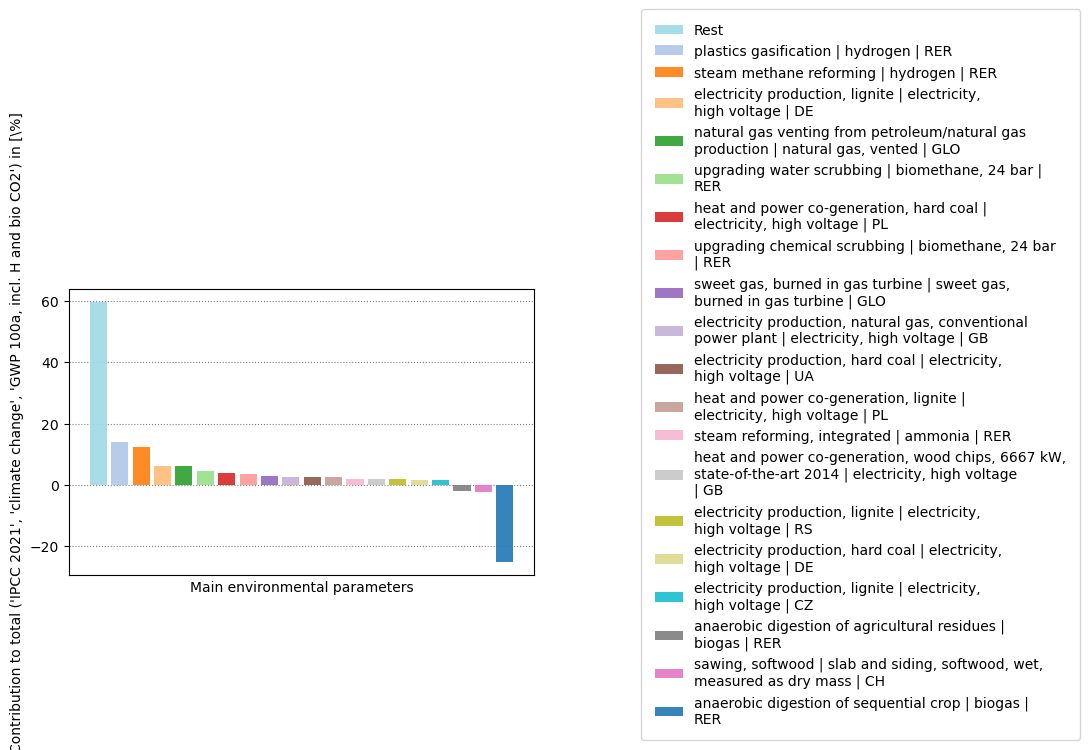

Characterized inventory: (2648, 23569) 26623
Filtered characterized inventory: (2648, 23569) 26623
Deviation from LCA score: 0.0
inventory (2648, 23569) filtering resulted in 26623 of 26623 exchanges (100.0% of total impact) and took 0.003 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 100 of 112 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
Parameters with uncertainty information: 19912 
Parameters without uncertainty information: 6656
In ammonia:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 55
Charactetization factors:
Parameters with uncertainty information: 0 
Parameters without uncertainty information: 100
Variable bounds:
Upper bound from choices without uncertainty information: 23
Upper bound from `upper_limit` without uncertainty information: 3
Lower bound from `lower_limit` without uncertainty information: 0


In [ ]:
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=0.,#0.000019,
    scaling_vector_strategy='constructed_demand',
    plot_results=True,
    plot_n_top_processes=19
)

The uncertainty strategies can be directly performed on the pulpo worker if the strategies are passed to the pulpo worker, else a standard trigional distribution is used

In [ ]:
unc_strategies = [
    processor.TriangularBoundInterpolationStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ecoinvent-3.10-cutoff',
        noise_interval={'min':.1, 'max':.1}
    ),
    
    processor.UniformBaseStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        upper_scaling_factor = .5,
        lower_scaling_factor = .5,
        noise_interval={'min':.2, 'max':.2}
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Cf',
        uncertain_param_subgroup=method,
        upper_scaling_factor = 0.15,
        lower_scaling_factor = 0.15,
        noise_interval={'min':.1, 'max':.1}
    ),
    processor.TriangluarBaseStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        upper_scaling_factor=.3,
        lower_scaling_factor=.3,
        noise_interval={'min':.2, 'max':.1}
    ),
    
    # processor.ExpertKnowledgeStrategy(
    #     uncertain_param_type='If',
    #     uncertain_param_subgroup='ammonia',
    #     prob_metadata={
    #         (80, 23548): {'minimum':.01 ,'maximum':.5, 'uncertainty_type':4}, # carbon dioxide storage and transport 200 km pipeline, storage 1000 m | carbon dioxide storage and transport 200 km pipeline, storage 1000 m | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    #         (80, 23538): {'minimum':.0002 ,'maximum':.002, 'uncertainty_type':4}, # transport, pipeline, supercritical carbon dioxide, 200 km without recompression | transport, pipeline, supercritical carbon dioxide, 200 km without recompression | RER --- Carbon dioxide, fossil | ('air', 'urban air close to ground')
    #     }
    # )
    ]

In [ ]:
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies)

Applying uncertainy strategy TriangularBoundInterpolationStrategy, for ecoinvent-3.10-cutoff in If
upper spread statistics
mean: 1.9299
mode: 0    3.466758
dtype: float64
median: 0.9529
std: 7.4716
min: 0.0287
max: 786.9859


lower spread statistics
mean: 0.6154
mode: 0    0.776124
dtype: float64
median: 0.4879
std: 7.2151
min: 0.0279
max: 786.9859

The upper spread scaling factor for intervention flows is: 0.9529236746994976
The lower spread scaling factor for intervention flows is: 0.4879472130749054
Applying uncertainy strategy UniformBaseStrategy, for ammonia in If
Applying uncertainy strategy TriangluarBaseStrategy, for ('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2') in Cf
Applying uncertainy strategy TriangluarBaseStrategy, for upper_limit in Var_bounds
No uncertainty data missing.


## 5. Define the global sensitivity problem

In [26]:
from SALib.sample import sobol as sample_method
from SALib.analyze import sobol as SA_method

The global sensitivity analysis can be called directly from the pulpo worker

In [27]:
# ATTN: Change method to string, as gsa has problems with dict ...
pulpo_worker.method = "('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')"

In [28]:
'''
pulpo_worker.run_gsa(
    result_data=result_data,
    sample_method=sample_method,
    SA_method=SA_method,
    sample_size=100,
    plot_gsa_results=True
)
'''

'\npulpo_worker.run_gsa(\n    result_data=result_data,\n    sample_method=sample_method,\n    SA_method=SA_method,\n    sample_size=100,\n    plot_gsa_results=True\n)\n'

In [29]:
# ATTN: Change back method to dict ...
pulpo_worker.method = {"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')": 1}

## 5. Chance constraint optimization

### 5.1. Formulate CC problem

There are different ways to formulate the chance constrain optimization problem:
- CC the objectives (uncertainties in the environmental costs)
- CC the variable bounds (also only individual bounds can be chance constrained):
    - scaling variable bounds (`UPPER_LIMT` and `LOWER_LIMIT`)
    - Inventory limit (`UPPER_INV_LIMIT` and `UPPER_IMP_LIMIT`)

The chance constraints can only be applied if the corresponding parameters have true uncertainty information specified.


Transform all uncertain parameter distributions to gausian distributions, since the CC formulation requires normal distributions

In [27]:
normal_uncertainty_data = processor.transform_to_normal(
    uncertainty_data,
    sample_size=100, 
    plot_distribution=False
    )

No uncertainty data missing.
26554 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
55 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
100 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
26 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation


Compute the standard deviation and mean for the environmental costs, assuming normally distributed intervention flows and characterization factors and using the L1 Norm to approximate the Square root.

$$
    \sqrt{\sum_j s_j^2 \cdot \sigma_{q_hb_j}^2}
$$

In [28]:
normal_metadata_env_cost = optimizer.compute_L1_env_cost_mean_var(
    normal_uncertainty_data= normal_uncertainty_data,
    lci_data=pulpo_worker.lci_data,
    method=method,
    plot_analysis_support_plots=False
)

These environmental costs have a standard deviation larger than 50% of their mean:

            std                                           metadata      mean  \
10556  0.553307  rape oil mill operation | rape oil, crude | Eu...  0.000037   
11402  0.122621  rape oil mill operation | rape meal | Europe w...  0.000009   
20708  0.762594  cottonseed oil mill operation | cottonseed oil...  0.011000   
982    0.759105  cottonseed oil mill operation | cottonseed oil...  0.011000   
5963   0.168438  cottonseed oil mill operation | cottonseed mea...  0.002447   
...         ...                                                ...       ...   
18376  0.051004  hard coal mine operation and hard coal prepara...  0.101409   
6088   0.000220  electricity production, hydro, reservoir, alpi...  0.000438   
10357  0.057922  butanols production, hydroformylation of propy...  0.115182   
19199  0.002787                    coke production | coal gas | US  0.005553   
6660   0.041761  heat production, co

Extract the variable bounds for which we want to impose CC for

In [29]:
CC_var_bounds = ['upper_limit'] # ATTN: Add other variable bounds here if needed
normal_metadata_var_bounds = {var_bound:normal_uncertainty_data['Var_bounds'][var_bound]['defined'] for var_bound in CC_var_bounds}


This can all be done in one step by calling the `create_CC_formulation` in the pulpo worker

In [30]:
normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

No uncertainty data missing.
No uncertainty data missing.
26554 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
55 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
100 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
26 parameters with non normal distribution are transformed into normal distributions via max likelihood approximation
These environmental costs have a standard deviation larger than 50% of their mean:

            std                                           metadata      mean  \
10556  0.516068  rape oil mill operation | rape oil, crude | Eu...  0.000037   
11402  0.120042  rape oil mill operation | rape meal | Europe w...  0.000009   
20708  0.856488  cottonseed oil mill operation | cottonseed oil...  0.011000   
982    0.837728  cottonseed oil mill operation | cottonseed oi

### 5.2. Solve one CC problem Pareto point

The CC problem is solved as a Pareto optimization using on environmental impact category and the probability level underlying the chance constraints.

Update the environmental costs and the variable bounds of the optimization problem based on the CC formulation. We are using a short cut here, where we compute the updated environmental costs and bound parameters based on the linear L1 gausian CC formulation

$$
    \big( \mu_{q_hb_j} + \Phi^{-1}(\lambda_{z_h}) \cdot \sigma_{q_hb_j} \big) 
$$

In [31]:
optimizer.apply_CC_formulation(
    lambda_level=0.8,
    normal_metadata_env_cost=normal_metadata_env_cost,
    normal_metadata_var_bounds=normal_metadata_var_bounds,
    model_instance=pulpo_worker.instance,
) 

Applying CC constraints to the environmental cost calculation with lambda: 0.8
Applying CC constraints to the upper_limit constraint with lambda: 0.8


Solve single Pareto point

In [32]:
pulpo_worker.solve()
pulpo_worker.summarize_results()
results = pulpo_worker.extract_results(extractparams=True)

Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47123 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47123 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23546 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23544 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  39006132865.44144


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')",1,3.900613e+10


## Choices Made

### biogas

...

### ammonia

,Value,Capacity
Metadata,,
nitrogen + hydrogen | ammonia | RER,1.710000e+10,1.000000e+20
"steam reforming, integrated | ammonia | RER",-0.000000e+00,1.000000e+20
"steam reforming, integrated (CCS) | ammonia | RER",-0.000000e+00,1.000000e+20


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23523,"(ammonia, fc378c5b9e61e417e77ba0c166897da5_copy1)",CCS 200km pipeline 1000m deep | CO2 stored | RER,4.439810e+09,5.000000e+09
23562,"(ammonia, f0a0840c698d6ebff3fbe10632efba3f_copy1)",treatment of waste PP | waste PP | RER,-0.000000e+00,1.875000e+09
23563,"(ammonia, db297644bd54c7a25b533be9246bc47b_copy1)",treatment of waste PS | waste PS | RER,-0.000000e+00,3.250000e+08


### 5.3. Solve the CC Problem using Epsilon Constraint method

Solve for an array of lambda epsilon constraints

In [ ]:
lambda_epsilon_array = np.linspace(0.5,1, 3, endpoint=False)
results_CC = {}
for lambda_level in lambda_epsilon_array:
    print(f'Solving for lambda = {lambda_level}')
    optimizer.apply_CC_formulation(
        lambda_level=lambda_level,
        normal_metadata_env_cost=normal_metadata_env_cost,
        normal_metadata_var_bounds=normal_metadata_var_bounds,
        model_instance=pulpo_worker.instance,
    ) 
    pulpo_worker.solve()
    results_CC[lambda_level] = pulpo_worker.extract_results(extractparams=True)
    pulpo_worker.summarize_results(zeroes=True)

Solving for lambda = 0.5
Applying CC constraints to the environmental cost calculation with lambda: 0.5
Applying CC constraints to the upper_limit constraint with lambda: 0.5
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47123 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47123 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23546 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23554 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  18567502709.837402


## Total Impact(s)

,Weight,Value
Method,,
"('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')",1,1.856750e+10


## Choices Made

### biogas

...

### ammonia

,Value,Capacity
Metadata,,
nitrogen + hydrogen | ammonia | RER,1.710000e+10,1.000000e+20


## Constraints

### Constraints Upper

,Key,Metadata,Value,Limit
ID,,,,
23523,"(ammonia, fc378c5b9e61e417e77ba0c166897da5_copy1)",CCS 200km pipeline 1000m deep | CO2 stored | RER,4.353623e+09,5.000000e+09


Plot Pareto front

With a cutoff value of 0.01, we keep 5 process to an error of 73.75%
With a cutoff value of 0.01, we keep 5 process to an error of 39.96%
With a cutoff value of 0.01, we keep 7 process to an error of 19.52%


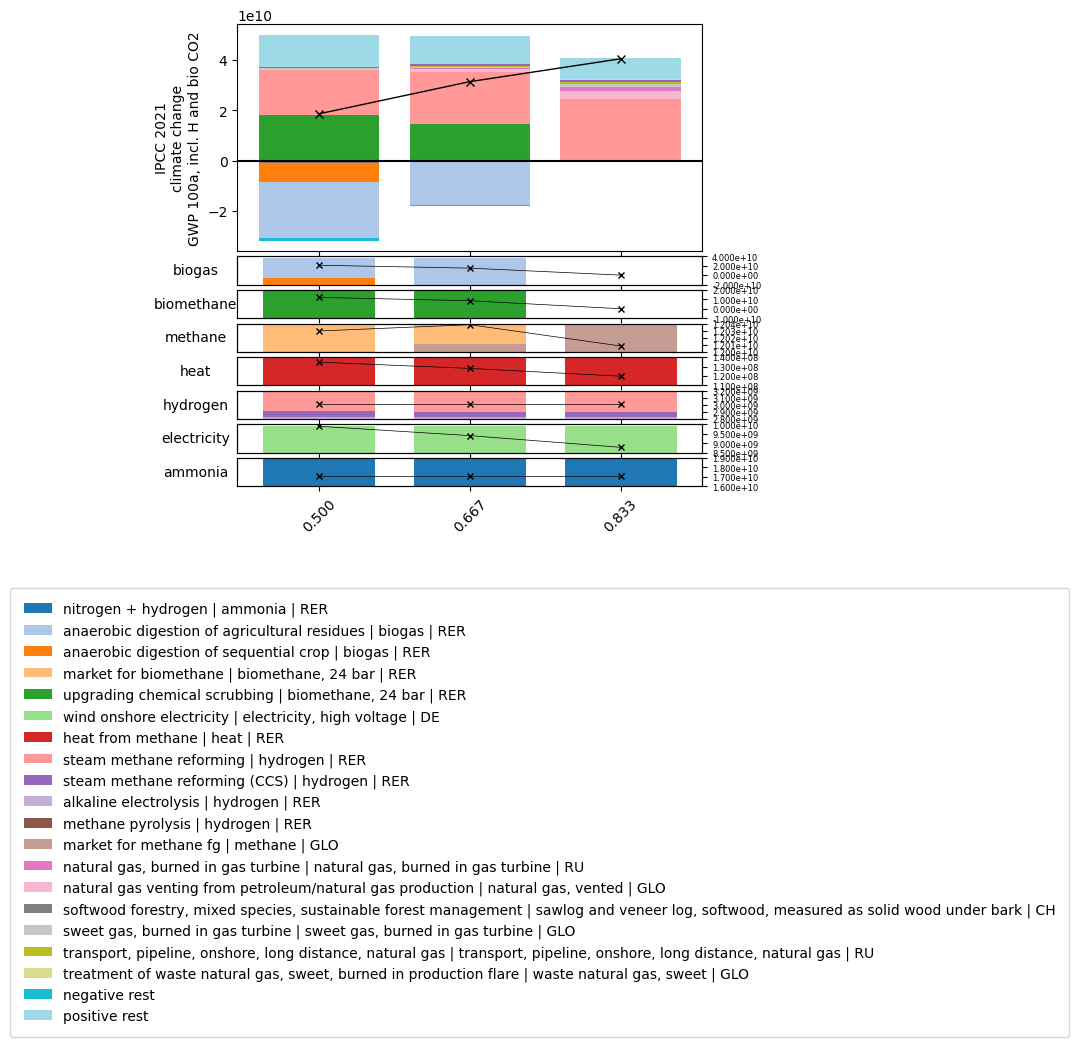

In [108]:
plots.plot_pareto_front(
    result_data_CC=results_CC, 
    cutoff_value=0.01, 
    method="\n".join(method.split("'")[1::2]), 
    process_map_metadata=pulpo_worker.lci_data['process_map_metadata'], 
    bbox_to_anchor=(0.65,-3.5),
    cmap_name='tab20'
    )


Compare the Pareto points

In [89]:
saver.compare_subsequent_paretosolutions(results_CC, choices, method)

('IPCC 2021', 'climate change', 'GWP 100a, incl. H and bio CO2')
0.5: 18578508563.36502
0.55: 22509440673.308453
0.6: 26530903855.12358
0.65: 30209250685.194828
0.7: 33747867864.522293
0.75: 37431068928.00324
0.8: 39427674140.02053
0.8500000000000001: 41778108274.16577
0.9: 44770890483.19909
0.95: 49279206265.90005


'biogas'

,Capacity,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95
Metadata,,,,,,,,,,,
anaerobic digestion of agricultural residues | biogas | RER,1.600000e+10,1.594493e+10,1.571736e+10,1.548613e+10,1.524713e+10,1.499526e+10,-0.0,-0.0,-0.0,-0.0,-0.0
anaerobic digestion of sequential crop | biogas | RER,1.400000e+10,4.942647e+09,5.194282e+09,5.449971e+09,-0.000000e+00,-0.000000e+00,-0.0,-0.0,-0.0,-0.0,-0.0


'biomethane'

,Capacity,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95
Metadata,,,,,,,,,,,
"upgrading chemical scrubbing | biomethane, 24 bar | RER",1.000000e+20,1.201417e+10,1.202801e+10,1.204208e+10,8.769881e+09,8.625010e+09,-0.0,-0.0,-0.0,-0.0,-0.0
"upgrading water scrubbing (CCS) | biomethane, 24 bar | RER",1.000000e+20,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.0,-0.0,-0.0,-0.0,-0.0
"upgrading water scrubbing | biomethane, 24 bar | RER",1.000000e+20,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.0,-0.0,-0.0,-0.0,-0.0
"upgrading chemical scrubbing (CCS) | biomethane, 24 bar | RER",1.000000e+20,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.000000e+00,-0.0,-0.0,-0.0,-0.0,-0.0


...


---

lambda_1: 0.8500000000000001
lambda_2: 0.9

Amount of process scaling variables that changed:
2842: >1% 
108: >10%
76: >100%
43: >1000%

Amount of process characterized scaling variables (impacts per process) that changed:
0: >1% 
0: >10%
0: >100%
0: >1000%

8.00420e-03: is the maximum impact change in one process
9.56683e-03: is the total impact change

The relative change of the characterized scaling vector (s_lambda_1 - s_lambda_2)*QB_s / QBs:



ID
steam methane reforming | hydrogen | RER                                                                                    0.008004
steam methane reforming (CCS) | hydrogen | RER                                                                              0.000606
natural gas venting from petroleum/natural gas production | natural gas, vented | GLO                                       0.000115
natural gas, burned in gas turbine | natural gas, burned in gas turbine | RU                                                0.000101
transport, pipeline, onshore, long distance, natural gas | transport, pipeline, onshore, long distance, natural gas | RU    0.000048
sweet gas, burned in gas turbine | sweet gas, burned in gas turbine | GLO                                                   0.000046
treatment of waste natural gas, sweet, burned in production flare | waste natural gas, sweet | GLO                          0.000025
electricity production, lignite | electricity, high voltage | DE  


---

lambda_1: 0.9
lambda_2: 0.95

Amount of process scaling variables that changed:
5302: >1% 
111: >10%
52: >100%
11: >1000%

Amount of process characterized scaling variables (impacts per process) that changed:
1: >1% 
0: >10%
0: >100%
0: >1000%

1.17468e-02: is the maximum impact change in one process
1.40325e-02: is the total impact change

The relative change of the characterized scaling vector (s_lambda_1 - s_lambda_2)*QB_s / QBs:



ID
steam methane reforming | hydrogen | RER                                                                                    0.011747
steam methane reforming (CCS) | hydrogen | RER                                                                              0.000883
natural gas venting from petroleum/natural gas production | natural gas, vented | GLO                                       0.000166
natural gas, burned in gas turbine | natural gas, burned in gas turbine | RU                                                0.000161
transport, pipeline, onshore, long distance, natural gas | transport, pipeline, onshore, long distance, natural gas | RU    0.000069
sweet gas, burned in gas turbine | sweet gas, burned in gas turbine | GLO                                                   0.000065
treatment of waste natural gas, sweet, burned in production flare | waste natural gas, sweet | GLO                          0.000036
electricity production, lignite | electricity, high voltage | DE  


---



## 5.4. Directly using the Pulpo Worker 

Using the pulpo worker

In [ ]:
results = pulpo_worker.solve_CC_problem(0.8, normal_metadata_env_cost, normal_metadata_var_bounds)

Applying CC constraints to the environmental cost calculation with lambda: 0.8
Applying CC constraints to the upper_limit constraint with lambda: 0.8
Running HiGHS 1.8.0 (git hash: eda5cbe): Copyright (c) 2024 HiGHS under MIT licence terms
Cols:       47123 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Cols:       47123 upper bounds greater than or equal to        1e+20 are treated as +Infinity
Rows:       23546 lower bounds    less than or equal to       -1e+20 are treated as -Infinity
Rows:       23544 upper bounds greater than or equal to        1e+20 are treated as +Infinity
optimal solution found:  39006132865.44144


Using the Pulpo worker

In [110]:
lambda_epsilon_array = np.linspace(0.5,1, 2, endpoint=False)
results_CC = pulpo_worker.solve_CC_problem(lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, plot_results=True)

TypeError: PulpoOptimizer.solve_CC_problem() got an unexpected keyword argument 'plot_results'